# AEGIS Sepsis Prediction — PhysioNet Dataset
**Adaptive Engine for Governance and Integrity Surveillance**

**Authors:** Farhad Abtahi and Mehdi Astaraki

**Developed by:** SMAILE at Karolinska Institutet

---

This notebook implements the AEGIS framework for trustworthy AI governance in
medical applications, demonstrated on the PhysioNet 2019 Sepsis Challenge dataset.

**Architecture** (see paper Section II):

| Module | Paper Section | Role |
|--------|--------------|------|
| **DARM** — Data Assimilation Module | II.B.1, Fig 1 | Dataset lifecycle: Golden / Training / Drifting splits |
| **MMM** — Model Monitoring Module | II.B.2, Fig 2 | Metrics, drift detection (Bonferroni-KS), MLcps |
| **CDM** — Conditional Decision Module | II.B.3, Table VI | PCCP governance decisions + parallel PMS ALARM |
| **Governor** | II.C, Fig 4 | Orchestrator: DARM → MMM → CDM per iteration |

**CDM Decision Categories** (Table VI):

PCCP Decision Chain (4 levels, priority order):

| Priority | Decision | Trigger |
|----------|----------|---------|
| P1 | REJECT | Sensitivity < 0.65 |
| P2 | CLINICAL_REVIEW | Sensitivity < 0.66 OR Specificity < 0.60 |
| P3 | CONDITIONAL_APPROVAL | Drift score in [0.30, 0.70] |
| P4 | APPROVE | All criteria pass + gold standard check |

PMS ALARM Signal (parallel, advisory — does NOT block deployment):

| Condition | Trigger |
|-----------|---------|
| A1 | Released model sensitivity on D_D < 0.65 |
| A2 | Released model regressed > 0.025 from baseline |
| A3 | Drift score > 0.90 |

**Simulation:** 11 iterations (0–10) designed to exercise all four PCCP categories plus PMS ALARM.

**Standalone notebook** — no external framework dependencies. Requires only: numpy, pandas, scikit-learn, scipy, matplotlib, shap.
Set `AEGIS_DATA_ROOT` environment variable or edit `DATA_ROOT` in the Setup cell.


## Section 1 — Setup & Imports

In [1]:
# ── Section 1: Setup & Imports ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import pickle
import json
import hashlib
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, Any, Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix, roc_curve,
    precision_recall_curve, auc, cohen_kappa_score,
    balanced_accuracy_score, matthews_corrcoef,
)

import shap

np.random.seed(42)

# ── Path Configuration ─────────────────────────────────────────────────────
# Set DATA_ROOT to the directory containing your PhysioNet sepsis data.
# Expected structure:
#   DATA_ROOT/
#     cache/
#       engineered_features_setA.pkl   (patient-level features, SetA)
#       engineered_features_setB.pkl   (patient-level features, SetB)
#     outputs/                         (created automatically)
#
# The .pkl files are pandas DataFrames with columns including:
#   - patient_id, SepsisLabel (target), Unit1, Unit2
#   - 202 engineered features (means, stds, slopes, etc.)
#
# To generate these from raw PhysioNet 2019 data, run the feature
# engineering pipeline (see preprocessing notebook or README).

DATA_ROOT = os.environ.get(
    "AEGIS_DATA_ROOT",
    "/Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject"
)
CACHE_PATH = os.path.join(DATA_ROOT, "cache")
OUTPUT_PATH = os.path.join(DATA_ROOT, "outputs")
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("AEGIS Sepsis Notebook — Setup complete")
print(f"  Data root : {DATA_ROOT}")
print(f"  Cache     : {CACHE_PATH}")
print(f"  Output    : {OUTPUT_PATH}")

AEGIS Sepsis Notebook — Setup complete
  Data root : /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject
  Cache     : /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/cache
  Output    : /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs


## Section 2 — AEGIS Framework (domain-agnostic)The four modules below are **domain-agnostic**: they know nothing about sepsis.Domain-specific configuration is injected in Section 3.

In [2]:
# ── Section 2a: DataAssimilationModule (DARM) ──────────────────────────────
# Paper reference: Section II.B.1, Figure 1
#
# Manages three dataset splits:
#   D_G (Golden)   — static, never modified after initialize()
#   D_T (Training) — accumulates every iteration (unconditionally)
#   D_D (Drifting) — current batch for drift comparison
#
# Key fix from current code: accumulate() is called EVERY iteration,
# not only when should_retrain is true.

class DataAssimilationModule:
    """AEGIS DARM — dataset lifecycle management (Section II.B.1)."""

    def __init__(self, golden_fraction: float = 0.20, random_state: int = 42):
        self.golden_fraction = golden_fraction
        self.random_state = random_state
        self.D_G: tuple = None          # (X, y) — static, never modified
        self.D_T: tuple = None          # (X, y) — accumulates each iteration
        self.D_D: tuple = None          # (X, y) — current batch
        self.iteration: int = 0
        self.provenance_log: list = []

    def initialize(self, X, y, patient_ids=None) -> tuple:
        """Split data into Golden (static) and Training (initial).

        Returns (X_iterative, y_iterative) — the remaining pool for batching.
        If patient_ids is provided, splitting is patient-safe.
        """
        if patient_ids is not None:
            # Patient-safe split: 20% patients → Golden, rest → pool
            splitter = GroupShuffleSplit(
                n_splits=1, test_size=1 - self.golden_fraction,
                random_state=self.random_state
            )
            golden_idx, pool_idx = next(splitter.split(X, y, groups=patient_ids))
        else:
            golden_idx, pool_idx = train_test_split(
                np.arange(len(X)), test_size=1 - self.golden_fraction,
                stratify=y, random_state=self.random_state
            )

        X_golden = X.iloc[golden_idx].reset_index(drop=True)
        y_golden = y.iloc[golden_idx].reset_index(drop=True)
        X_pool   = X.iloc[pool_idx].reset_index(drop=True)
        y_pool   = y.iloc[pool_idx].reset_index(drop=True)

        # Pool split: 50% → initial D_T, 50% → iterative batches
        split_point = len(X_pool) // 2
        X_T_init = X_pool.iloc[:split_point].reset_index(drop=True)
        y_T_init = y_pool.iloc[:split_point].reset_index(drop=True)
        X_iter   = X_pool.iloc[split_point:].reset_index(drop=True)
        y_iter   = y_pool.iloc[split_point:].reset_index(drop=True)

        self.D_G = (X_golden.copy(), y_golden.copy())
        self.D_T = (X_T_init.copy(), y_T_init.copy())

        print(f"  DARM initialized:")
        print(f"    D_G (Golden)   : {len(X_golden):,} patients  (sepsis rate {y_golden.mean():.1%})")
        print(f"    D_T (Training) : {len(X_T_init):,} patients  (sepsis rate {y_T_init.mean():.1%})")
        print(f"    Iterative pool : {len(X_iter):,} patients  (sepsis rate {y_iter.mean():.1%})")

        return X_iter, y_iter

    def ingest_batch(self, X_batch, y_batch, metadata: dict):
        """Assign new observations to D_D. Log provenance."""
        self.D_D = (X_batch.copy().reset_index(drop=True),
                     y_batch.copy().reset_index(drop=True))
        self.provenance_log.append({
            "iteration": self.iteration,
            "n_samples": len(X_batch),
            "sepsis_rate": float(y_batch.mean()),
            "metadata": metadata,
        })

    def accumulate(self):
        """D_{T,k+1} = D_{T,k} ∪ D_{D,k}. Called unconditionally every iteration."""
        X_T, y_T = self.D_T
        X_D, y_D = self.D_D
        self.D_T = (
            pd.concat([X_T, X_D], ignore_index=True),
            pd.concat([y_T, y_D], ignore_index=True),
        )
        self.iteration += 1

    # ── Accessors ──
    def get_golden(self)        -> tuple: return self.D_G
    def get_training(self)      -> tuple: return self.D_T
    def get_drifting(self)      -> tuple: return self.D_D
    def get_training_size(self) -> int:   return len(self.D_T[0])

print("DataAssimilationModule (DARM) defined.")

DataAssimilationModule (DARM) defined.


In [3]:
# ── Section 2b: ModelMonitoringModule (MMM) ────────────────────────────────
# Paper reference: Section II.B.2, Figure 2, Table II
#
# Fixes from current code:
#   - Drift = fraction of K key features exceeding Bonferroni-corrected threshold
#     (was: mean(1-p) across all 202 features)
#   - MLcps via polar-coordinate area calculation (paper ref [12])
#   - No hardcoded trustworthy AI values

@dataclass
class MonitoringConfig:
    drift_features: list                        # Key clinical features for drift
    drift_alpha: float = 0.05                   # Base significance level
    major_drift_threshold: float = 0.90
    minor_drift_low: float = 0.35
    minor_drift_high: float = 0.70
    mlcps_metrics: list = None                  # Metric labels for MLcps
    mlcps_weights: dict = None                  # {metric_label: weight}


class ModelMonitoringModule:
    """AEGIS MMM — continuous monitoring (Section II.B.2)."""

    def __init__(self, config: MonitoringConfig):
        self.config = config
        self.kpi_history: list = []

    # ── Performance evaluation ─────────────────────────────────────────────
    def evaluate_performance(self, model, X, y) -> dict:
        """Full metric computation on one dataset split."""
        y_proba = model.predict_proba(X)[:, 1]
        y_pred = (y_proba >= model.optimal_threshold).astype(int)
        cm = confusion_matrix(y, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        metrics = {
            "sensitivity": sens,
            "specificity": spec,
            "roc_auc": roc_auc_score(y, y_proba),
            "ppv": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
            "npv": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
            "f1": f1_score(y, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y, y_pred),
            "matthews_corr": matthews_corrcoef(y, y_pred),
            "cohen_kappa": cohen_kappa_score(y, y_pred),
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
        }
        # PR-AUC
        prec_vals, rec_vals, _ = precision_recall_curve(y, y_proba)
        metrics["pr_auc"] = auc(rec_vals, prec_vals)
        # MLcps
        metrics["mlcps"] = self.compute_mlcps(metrics)
        return metrics

    # ── Drift detection (Bonferroni-corrected KS) ──────────────────────────
    def compute_drift_score(self, X_reference, X_new) -> dict:
        """Paper formula: DriftScore = (1/K) * sum(I[p_i < alpha'])
        where K = len(drift_features), alpha' = alpha / K (Bonferroni).
        """
        cfg = self.config
        drift_feats = [f for f in cfg.drift_features if f in X_reference.columns and f in X_new.columns]
        K = len(drift_feats)
        if K == 0:
            return {"drift_score": 0.0, "major_drift": False, "minor_drift": False,
                    "n_shifted": 0, "n_tested": 0, "feature_results": {}}

        alpha_corrected = cfg.drift_alpha / K
        n_shifted = 0
        feature_results = {}

        for feat in drift_feats:
            ref_vals = X_reference[feat].dropna()
            new_vals = X_new[feat].dropna()
            if len(ref_vals) < 5 or len(new_vals) < 5:
                feature_results[feat] = {"p_value": 1.0, "shifted": False}
                continue
            stat, p_val = ks_2samp(ref_vals, new_vals)
            shifted = p_val < alpha_corrected
            n_shifted += int(shifted)
            feature_results[feat] = {"statistic": stat, "p_value": p_val, "shifted": shifted}

        drift_score = n_shifted / K
        return {
            "drift_score": round(drift_score, 3),
            "major_drift": drift_score > cfg.major_drift_threshold,
            "minor_drift": cfg.minor_drift_low < drift_score <= cfg.minor_drift_high,
            "n_shifted": n_shifted,
            "n_tested": K,
            "feature_results": feature_results,
        }

    # ── MLcps (polar-coordinate area, ref [12]) ────────────────────────────
    def compute_mlcps(self, metrics: dict) -> float:
        """MLcps via polar-coordinate area with clinical-priority weighting.

        Projects N metrics onto equally-spaced angular sectors in polar
        coordinates, scales sector angles by weights, and computes the
        enclosed area.  Matches the algorithm in:
            Akshay et al., GigaScience 12, giad108 (2023)

        This is a pure-Python implementation (no R dependency).
        """
        cfg = self.config
        if cfg.mlcps_metrics is None:
            return 0.0

        key_map = {
            "Sensitivity": "sensitivity",
            "ROC-AUC": "roc_auc",
            "Balanced_Accuracy": "balanced_accuracy",
            "Specificity": "specificity",
        }
        values = []
        raw_weights = []
        for m in cfg.mlcps_metrics:
            val = metrics.get(key_map.get(m, m), 0.0)
            values.append(max(0.0, min(1.0, val)))
            w = cfg.mlcps_weights.get(m, 1.0) if cfg.mlcps_weights else 1.0
            raw_weights.append(w)

        n = len(values)
        if n < 2:
            return values[0] if values else 0.0

        # Normalize weights to sum to 2*pi
        total_w = sum(raw_weights)
        angles = [2 * np.pi * w / total_w for w in raw_weights]

        # Polar-coordinate area: sum of triangular sectors
        area = 0.0
        for i in range(n):
            r1 = values[i]
            r2 = values[(i + 1) % n]
            theta = angles[i]
            area += 0.5 * r1 * r2 * np.sin(theta)

        # Normalize by area of unit circle
        max_area = 0.0
        for i in range(n):
            max_area += 0.5 * 1.0 * 1.0 * np.sin(angles[i])

        score = area / max_area if max_area > 0 else 0.0
        return round(max(0.0, min(1.0, score)), 4)

    # ── Bias proxy ─────────────────────────────────────────────────────────
    def compute_bias_score(self, model, X, y, split_feature: str) -> float:
        """Fairness proxy: |Sensitivity_group0 - Sensitivity_group1|.
        Uses median split on split_feature as a demographic proxy.
        NOTE: True demographic fairness requires demographic variables
        not available in PhysioNet data.
        """
        median_val = X[split_feature].median()
        mask = X[split_feature] > median_val
        if mask.sum() < 10 or (~mask).sum() < 10:
            return 0.0
        m0 = self.evaluate_performance(model, X[~mask], y[~mask])
        m1 = self.evaluate_performance(model, X[mask], y[mask])
        return round(abs(m0["sensitivity"] - m1["sensitivity"]), 4)

    # ── SHAP explainability ────────────────────────────────────────────────
    def compute_explainability(self, model, X_sample) -> float:
        """SHAP-based explainability: concentration ratio of top-5 features."""
        try:
            explainer = shap.TreeExplainer(model.model)
            sv = explainer.shap_values(X_sample[:100])
            if isinstance(sv, list):
                sv = sv[1]
            mean_abs = np.abs(sv).mean(axis=0).flatten()
            top5 = np.sort(mean_abs)[-5:].sum()
            total = mean_abs.sum()
            return round(top5 / total, 4) if total > 0 else 0.0
        except Exception:
            return float("nan")

    # ── Record keeping ─────────────────────────────────────────────────────
    def record_iteration(self, iteration: int, golden_metrics: dict,
                         drifting_metrics: dict, drift_results: dict,
                         decision: dict, training_size: int,
                         released_on_drifting: dict = None):
        """Append to KPI history for audit trail and visualization.

        released_on_drifting: Performance of the last *approved* model
        evaluated on D_D (new batch).  This is the performance-drift
        signal that complements KS-based feature-distribution drift.
        """
        self.kpi_history.append({
            "iteration": iteration,
            "golden": golden_metrics,
            "drifting": drifting_metrics,
            "drift": drift_results,
            "decision": decision["decision"],
            "trigger_reasons": decision["trigger_reasons"],
            "pms_alarm": decision.get("pms_alarm", False),
            "pms_alarm_reasons": decision.get("pms_alarm_reasons", []),
            "training_size": training_size,
            "released_on_drifting": released_on_drifting,
        })

print("ModelMonitoringModule (MMM) defined.")


ModelMonitoringModule (MMM) defined.


In [4]:
# ── Section 2c: ConditionalDecisionModule (CDM) ───────────────────────────
# Paper reference: Section II.B.3, Table III, Table V, Table VI, Figure 3
#
# Dual-output architecture:
#   Part A — PCCP Decision: P1 REJECT → P2 CLINICAL_REVIEW →
#            P3 CONDITIONAL_APPROVAL → P4 APPROVE
#   Part B — PMS ALARM Signal: A1 / A2 / A3 (parallel advisory)
#
# The CDM answers two independent questions at every iteration:
#   1. "Can the new candidate model be deployed?" → PCCP Decision
#   2. "Is the currently released model still safe in the field?" → PMS ALARM
#
# APPROVE + PMS ALARM is not contradictory: it means the new model passes all
# deployment checks while the released model is simultaneously flagged as at risk.

@dataclass
class DecisionConfig:
    # ── PCCP thresholds ──
    # P1: REJECT — safety floor
    critical_sensitivity: float = 0.65
    # P2: CLINICAL_REVIEW — performance buffer zone
    review_sensitivity: float = 0.66
    review_specificity: float = 0.60
    # P3: CONDITIONAL_APPROVAL — minor drift
    minor_drift_low: float = 0.30
    minor_drift_high: float = 0.70
    # P4: APPROVE — gold standard tolerance
    gold_standard_tolerance: float = 0.015
    # ── PMS ALARM thresholds (parallel advisory signal) ──
    major_drift_threshold: float = 0.90       # A3
    pms_sensitivity_floor: float = 0.65       # A1 (qualified by A3)
    pms_regression_delta: float = 0.025       # A2: stub — not yet implemented, see Section IV-I


class ConditionalDecisionModule:
    """AEGIS CDM — PCCP governance decisions + PMS ALARM (Section II.B.3, Table VI)."""

    def __init__(self, config: DecisionConfig):
        self.config = config
        self.gold_standard: dict = None
        self.last_released_metrics: dict = None
        self.decision_log: list = []

    def set_gold_standard(self, metrics: dict):
        """Store validated metrics after first APPROVE (Section II.B.4)."""
        self.gold_standard = metrics.copy()
        self.last_released_metrics = metrics.copy()

    def update_released(self, metrics: dict):
        """Update last-released baseline after subsequent APPROVE."""
        self.last_released_metrics = metrics.copy()

    def evaluate(self, golden_metrics: dict, drift_results: dict,
                 drifting_metrics: dict = None,
                 released_on_drifting: dict = None) -> dict:
        """Dual-output evaluation: PCCP decision + parallel PMS ALARM.

        PMS ALARM is evaluated FIRST so that the PCCP chain can defer the
        gold standard check when the drift signal already explains metric
        variation (Table VI, P4 note).
        """
        # Part B first: PMS ALARM Signal (currently released model)
        alarm, alarm_reasons = self._evaluate_pms_alarm(drift_results, released_on_drifting)

        # Part A: PCCP Decision (new candidate model)
        # Pass alarm status so P4 can defer gold standard when appropriate
        pccp = self._evaluate_pccp(golden_metrics, drift_results, pms_alarm=alarm)

        entry = {
            "decision":          pccp["label"],
            "trigger_reasons":   pccp["reasons"],
            "required_actions":  pccp["actions"],
            "pms_alarm":         alarm,
            "pms_alarm_reasons": alarm_reasons,
        }
        self.decision_log.append(entry)
        return entry

    def _evaluate_pccp(self, golden_metrics: dict, drift_results: dict,
                       pms_alarm: bool = False) -> dict:
        """4-level PCCP decision chain (Table VI Part A).

        P1: sensitivity < 0.65              → REJECT
        P2: sens < 0.66 OR spec < 0.60     → CLINICAL_REVIEW
        P3: drift in [0.30, 0.70]          → CONDITIONAL_APPROVAL
        P4: all pass + gold standard check  → APPROVE
            (gold standard deferred when PMS ALARM active)
        """
        c = self.config
        sens = golden_metrics["sensitivity"]
        spec = golden_metrics["specificity"]
        ds = drift_results["drift_score"]

        # P1 — Safety floor
        if sens < c.critical_sensitivity:
            return self._label("REJECT",
                [f"sensitivity={sens:.3f} < {c.critical_sensitivity} (safety violation)"],
                ["Block deployment", "Rollback to last approved model",
                 "Initiate root cause analysis"])

        # P2 — Performance buffer zone
        if sens < c.review_sensitivity or spec < c.review_specificity:
            reasons = []
            if sens < c.review_sensitivity:
                reasons.append(f"sensitivity={sens:.3f} < {c.review_sensitivity}")
            if spec < c.review_specificity:
                reasons.append(f"specificity={spec:.3f} < {c.review_specificity}")
            return self._label("CLINICAL_REVIEW", reasons,
                ["Require human clinical review before deployment",
                 "Evaluate model on subpopulations"])

        # P3 — Minor drift
        if drift_results["minor_drift"]:
            return self._label("CONDITIONAL_APPROVAL",
                [f"minor drift detected: score={ds:.3f} in [{c.minor_drift_low}, {c.minor_drift_high}]"],
                ["Deploy with enhanced monitoring frequency",
                 "Schedule re-evaluation in next cycle"])

        # P4 — All pass + gold standard comparison
        # When PMS ALARM is active, defer gold standard check — the drift
        # signal already explains metric variation.  The PMS investigation
        # will determine whether the model needs correction.
        if pms_alarm:
            return self._label("APPROVE",
                ["PCCP criteria satisfied",
                 "Gold standard deferred (PMS ALARM active)"],
                ["Deploy model", "Update audit log",
                 "Initiate PMS drift investigation"])

        gs_check = self._check_gold_standard(golden_metrics)
        if not gs_check["passed"]:
            return self._label("CLINICAL_REVIEW",
                [f"gold standard regression: {gs_check['detail']}"],
                ["Review performance trend against baseline"])

        return self._label("APPROVE",
            ["All PCCP criteria satisfied", "Gold standard passed"],
            ["Deploy model", "Update audit log"])

    def _evaluate_pms_alarm(self, drift_results: dict,
                            released_on_drifting: dict = None) -> tuple:
        """PMS ALARM — 3 conditions on the released model (Table VI Part B).

        A3: drift_score > major_drift_threshold (0.90)
            → Major distributional shift threatens released model validity
        A1: released model sensitivity on D_D < pms_sensitivity_floor (0.65)
            → Only evaluated when A3 fires; qualifies severity

        Returns (bool, list[str]).
        """
        c = self.config
        alarm = False
        reasons = []

        ds = drift_results["drift_score"]

        # A3: Major distribution drift (primary PMS trigger)
        if ds > c.major_drift_threshold:
            alarm = True
            reasons.append(
                f"A3: drift_score={ds:.3f} > {c.major_drift_threshold} "
                f"(major distribution shift)")

            # A1: Released model PMS floor breach (qualifies A3)
            if released_on_drifting is not None:
                rel_sens = released_on_drifting.get("sensitivity", 1.0)
                if rel_sens < c.pms_sensitivity_floor:
                    reasons.append(
                        f"A1: released model sens on D_D={rel_sens:.3f} "
                        f"< {c.pms_sensitivity_floor}")

        return alarm, reasons

    def _check_gold_standard(self, metrics: dict) -> dict:
        """Gold standard comparison — sensitivity regression from iter-0 baseline."""
        if self.gold_standard is None:
            return {"passed": True, "detail": "No baseline yet"}
        tol = self.config.gold_standard_tolerance
        if "sensitivity" in self.gold_standard:
            diff = metrics["sensitivity"] - self.gold_standard["sensitivity"]
            if diff < -tol:
                return {"passed": False,
                        "detail": f"sensitivity dropped {diff:+.3f} from baseline "
                                  f"{self.gold_standard['sensitivity']:.3f}"}
        return {"passed": True, "detail": "Within tolerance"}

    def _label(self, label: str, reasons: list, actions: list) -> dict:
        """Build a PCCP label dict (does NOT append to log — evaluate() does that)."""
        return {"label": label, "reasons": reasons, "actions": actions}

print("ConditionalDecisionModule (CDM) defined — PCCP chain + parallel PMS ALARM.")


ConditionalDecisionModule (CDM) defined — PCCP chain + parallel PMS ALARM.


In [5]:
# ── Section 2d: AEGISGovernor ──────────────────────────────────────────────
# Paper reference: Section II.C, Figure 4
#
# Orchestrates DARM -> MMM -> CDM per iteration.
# Key: accumulate() is called BEFORE retraining, so D_T grows unconditionally.
# Model is always retrained on the updated D_T.

class AEGISGovernor:
    """Orchestrates DARM -> MMM -> CDM per iteration (Section II.C, Figure 4)."""

    def __init__(self, darm: DataAssimilationModule,
                 mmm: ModelMonitoringModule,
                 cdm: ConditionalDecisionModule,
                 model_factory: callable):
        self.darm = darm
        self.mmm = mmm
        self.cdm = cdm
        self.model_factory = model_factory
        self.current_model = None
        self.approved_model = None

    def run_initial(self) -> dict:
        """Iteration 0: train on initial D_T, evaluate on D_G, establish gold standard."""
        X_T, y_T = self.darm.get_training()
        X_G, y_G = self.darm.get_golden()

        self.current_model = self.model_factory()
        self.current_model.train(X_T, y_T)

        golden_metrics = self.mmm.evaluate_performance(self.current_model, X_G, y_G)
        null_drift = {"drift_score": 0.0, "major_drift": False,
                      "minor_drift": False, "n_shifted": 0, "n_tested": 0,
                      "feature_results": {}}

        decision = self.cdm.evaluate(golden_metrics, null_drift)

        if decision["decision"] == "APPROVE":
            self.cdm.set_gold_standard(golden_metrics)
            self.approved_model = self.current_model

        self.mmm.record_iteration(0, golden_metrics, None, null_drift,
                                  decision, self.darm.get_training_size())
        return decision

    def run_iteration(self, X_batch, y_batch, metadata: dict) -> dict:
        """One AEGIS iteration k >= 1."""
        # ── DARM: ingest ──
        self.darm.ingest_batch(X_batch, y_batch, metadata)
        X_G, y_G = self.darm.get_golden()
        X_D, y_D = self.darm.get_drifting()

        # ── MMM: drift detection (compare new batch vs current D_T) ──
        # Reference = D_T before accumulation. This detects distributional
        # differences between incoming data and what the model was trained on.
        # Using D_T (not D_G) provides a non-zero baseline during stationary
        # operation, making the transition to drift scenarios less binary.
        X_ref, _ = self.darm.get_training()   # D_T before accumulation
        drift_results = self.mmm.compute_drift_score(X_ref, X_D)

        # ── MMM: performance drift (last approved model on new data) ──
        # Evaluates whether the released model still performs adequately on
        # the incoming batch.  This detects concept drift and label-quality
        # issues that KS-based feature-drift may miss (Section II.B.2).
        released_on_drifting = None
        if self.approved_model is not None and len(y_D) > 10:
            released_on_drifting = self.mmm.evaluate_performance(
                self.approved_model, X_D, y_D)

        # ── DARM: accumulate (unconditional) ──
        self.darm.accumulate()

        # ── Train new model on updated D_T ──
        X_T_new, y_T_new = self.darm.get_training()
        new_model = self.model_factory()
        new_model.train(X_T_new, y_T_new)

        # ── MMM: evaluate new model on both splits ──
        golden_metrics = self.mmm.evaluate_performance(new_model, X_G, y_G)
        drifting_metrics = self.mmm.evaluate_performance(new_model, X_D, y_D)

        # ── CDM: decision ──
        decision = self.cdm.evaluate(golden_metrics, drift_results, drifting_metrics,
                                     released_on_drifting=released_on_drifting)

        # ── Act on decision ──
        # PMS ALARM is advisory — it does NOT trigger rollback.
        # Only REJECT blocks deployment and rolls back.
        if decision["decision"] == "APPROVE":
            self.approved_model = new_model
            self.current_model = new_model
            self.cdm.update_released(golden_metrics)
        elif decision["decision"] in ("CONDITIONAL_APPROVAL", "CLINICAL_REVIEW"):
            self.current_model = new_model   # tentative deployment
        elif decision["decision"] == "REJECT":
            self.current_model = self.approved_model   # rollback

        # ── MMM: record ──
        self.mmm.record_iteration(
            self.darm.iteration, golden_metrics, drifting_metrics,
            drift_results, decision, self.darm.get_training_size(),
            released_on_drifting=released_on_drifting)

        return decision

print("AEGISGovernor defined.")


AEGISGovernor defined.


## Section 3 — Sepsis Instantiation (configuration only)This section is **domain-specific**: it defines the 34 drift features, the modelfactory (Random Forest), and wires everything into the Governor.> Paper reference: Section II.D, Table IV, Table VII

In [6]:
# ── Section 3: Sepsis Instantiation ────────────────────────────────────────

# ── 3a: Data loading ───────────────────────────────────────────────────────
print("=" * 80)
print("DATA LOADING")
print("=" * 80)

cache_A = os.path.join(CACHE_PATH, "engineered_features_setA.pkl")
cache_B = os.path.join(CACHE_PATH, "engineered_features_setB.pkl")

with open(cache_A, "rb") as f:
    setA_data = pickle.load(f)
with open(cache_B, "rb") as f:
    setB_data = pickle.load(f)

print(f"  SetA: {len(setA_data):,} patients, {setA_data.shape[1]} features")
print(f"  SetB: {len(setB_data):,} patients, {setB_data.shape[1]} features")

# Features and labels
feature_cols = [c for c in setA_data.columns
                if c not in ("patient_id", "SepsisLabel", "Unit1", "Unit2")]
X_setA = setA_data[feature_cols]
y_setA = setA_data["SepsisLabel"]

print(f"  Feature columns : {len(feature_cols)}")
print(f"  Sepsis rate     : {y_setA.mean():.1%}  ({int(y_setA.sum()):,} / {len(y_setA):,})")

# ── 3b: Configuration ─────────────────────────────────────────────────────

# 34 Key Clinical Features for Drift Detection
# Selected based on clinical relevance to sepsis pathophysiology.
SEPSIS_DRIFT_FEATURES = [
    # Vital signs (means and variability)
    "HR_mean", "HR_std", "O2Sat_mean", "O2Sat_std",
    "SBP_mean", "SBP_std", "DBP_mean", "MAP_mean",
    "Resp_mean", "Resp_std", "Temp_mean", "Temp_std",
    # Key laboratory values
    "WBC_mean", "Platelets_mean", "Lactate_mean", "Creatinine_mean",
    "BUN_mean", "Glucose_mean", "pH_mean", "BaseExcess_mean",
    "HCO3_mean", "FiO2_mean", "PaCO2_mean", "Bilirubin_total_mean",
    "Hgb_mean", "Fibrinogen_mean",
    # Derived / ICU stay
    "ICULOS_max", "Age",
    # Slope features (trend indicators)
    "HR_slope", "Resp_slope", "SBP_slope", "Lactate_slope", "WBC_slope",
    "Temp_slope",
]
# Verify presence
present = [f for f in SEPSIS_DRIFT_FEATURES if f in feature_cols]
print(f"  Drift features  : {len(present)}/{len(SEPSIS_DRIFT_FEATURES)} present in data")

monitoring_config = MonitoringConfig(
    drift_features=SEPSIS_DRIFT_FEATURES,
    drift_alpha=0.05,
    major_drift_threshold=0.90,
    minor_drift_low=0.30,
    minor_drift_high=0.70,
    mlcps_metrics=["Sensitivity", "ROC-AUC", "Balanced_Accuracy", "Specificity"],
    mlcps_weights={
        "Sensitivity": 1.5, "ROC-AUC": 1.3,
        "Balanced_Accuracy": 1.1, "Specificity": 1.0,
    },
)

decision_config = DecisionConfig(
    critical_sensitivity=0.65,
    review_sensitivity=0.66,     # widened from 0.68 — see calibration analysis
    review_specificity=0.60,     # widened from 0.70 — see calibration analysis
    minor_drift_low=0.30,        # widened from 0.35 for robustness
    minor_drift_high=0.70,
    gold_standard_tolerance=0.015, # Detects subtle sens regression (>1.5% decline from baseline)
    major_drift_threshold=0.90,       # A3: PMS ALARM
    pms_sensitivity_floor=0.65,       # A1: PMS ALARM
    pms_regression_delta=0.025,       # A2: PMS ALARM
)

# ── 3c: Model Factory ─────────────────────────────────────────────────────

class SepsisRFModel:
    """Thin wrapper around RandomForestClassifier for AEGIS interface.

    Hyperparameters selected for inter-iteration stability rather than
    maximum predictive power.  The governance demonstration requires
    that metric changes reflect data perturbations, not model instability.

    Key design choices (see paper Table VII):
      max_depth=12        : stable across D_T sizes 8k-25k
      min_samples_leaf=5  : prevents tiny leaves
      class_weight=bal    : sklearn-computed weights (~ 1:11.4 for 8.8% sepsis)
      no StandardScaler   : RF is invariant to monotonic feature transforms
      no internal split   : threshold optimised on OOB for consistency;
                            the static Golden set provides unbiased evaluation
    """

    def __init__(self):
        self.model = RandomForestClassifier(
            n_estimators=300,
            max_depth=12,            # was 12 — prevents overfit at large D_T
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            oob_score=True,
            random_state=42,
            n_jobs=-1,
        )
        self.imputer = SimpleImputer(strategy="median")
        self.optimal_threshold = 0.5

    def train(self, X, y):
        X_proc = self.imputer.fit_transform(X)
        self.model.fit(X_proc, y)
        self._optimize_threshold_oob(y, target_sensitivity=0.75)

    def predict_proba(self, X):
        X_proc = self.imputer.transform(X)
        return self.model.predict_proba(X_proc)

    def _optimize_threshold_oob(self, y, target_sensitivity):
        """Optimize threshold using OOB (out-of-bag) predictions.

        OOB predictions provide honest, cross-validated probability
        estimates without needing a holdout set.  Each tree predicts
        only on samples it did NOT train on, so the threshold is
        calibrated on truly unseen data — no overfitting, no split
        variance, and no need for a separate validation fold.
        """
        y_proba = self.model.oob_decision_function_[:, 1]
        fpr_, tpr_, thresholds = roc_curve(y, y_proba)
        idx = np.argmin(np.abs(tpr_ - target_sensitivity))
        self.optimal_threshold = float(thresholds[idx])


def sepsis_model_factory():
    return SepsisRFModel()


# ── 3d: Assemble Governor ─────────────────────────────────────────────────
darm = DataAssimilationModule(golden_fraction=0.20, random_state=42)
mmm  = ModelMonitoringModule(monitoring_config)
cdm  = ConditionalDecisionModule(decision_config)
governor = AEGISGovernor(darm, mmm, cdm, sepsis_model_factory)

print()
print("AEGIS Governor assembled:")
print(f"  DARM  : golden_fraction={darm.golden_fraction}")
print(f"  MMM   : {len(monitoring_config.drift_features)} drift features, alpha={monitoring_config.drift_alpha}")
print(f"  CDM   : P1<{decision_config.critical_sensitivity}, "
      f"P2<{decision_config.review_sensitivity}/{decision_config.review_specificity}, "
      f"P3=[{decision_config.minor_drift_low},{decision_config.minor_drift_high}], "
      f"P4=APPROVE")
print(f"  PMS   : A1<{decision_config.pms_sensitivity_floor}(sens), "
      f"A2>{decision_config.pms_regression_delta}(delta), "
      f"A3>{decision_config.major_drift_threshold}(drift)")

DATA LOADING
  SetA: 20,335 patients, 204 features
  SetB: 20,000 patients, 210 features
  Feature columns : 202
  Sepsis rate     : 8.8%  (1,790 / 20,335)
  Drift features  : 34/34 present in data

AEGIS Governor assembled:
  DARM  : golden_fraction=0.2
  MMM   : 34 drift features, alpha=0.05
  CDM   : P1<0.65, P2<0.66/0.6, P3=[0.3,0.7], P4=APPROVE
  PMS   : A1<0.65(sens), A2>0.025(delta), A3>0.9(drift)


## Section 4 — Synthetic Scenario Preparation

Scenarios are designed to exercise all four PCCP decision categories plus the PMS ALARM signal.
Each synthetic iteration demonstrates one governance concept without contaminating subsequent iterations.
Recovery (iter 9) is placed before catastrophic failure (iter 10) so accumulated corruption is manageable.

| Iter | Source | Scenario | Target PCCP | PMS ALARM | Teaching Point |
|------|--------|----------|-------------|-----------|----------------|
| 0 | Real (initial D_T) | Baseline | APPROVE | No | Gold standard established |
| 1–5 | Real batches (SetA) | Stationary | APPROVE | No | Stable governance; metrics in tight band |
| 6 | 50% SetA + 50% SetB | Cross-site drift | CONDITIONAL_APPROVAL | No | Minor drift (0.30–0.70) triggers enhanced monitoring |
| 7 | Clean SetA (n=3000) | Gold std regression | CLINICAL_REVIEW | No | Subtle sensitivity regression caught by gold standard check |
| 8 | Extreme drift (n=100) | Major drift | APPROVE | Yes (A3) | New model passes PCCP; PMS flags released model at risk |
| 9 | Clean SetA (n=3000) | Recovery | APPROVE | No | System recovers after drift; all metrics restored |
| 10 | Corrupted (n=25000) | Catastrophic failure | REJECT | Yes (A1+A3) | Safety floor blocks deployment; PMS co-fires |

**Performance-drift signal (Perf.Sens/Spec on D_D):** At each iteration, the *last approved* model
is also evaluated on the incoming batch D_D. This detects concept drift — situations where feature
distributions look normal but the model's predictions degrade on the new population.


In [7]:
# ── Section 4: Synthetic Scenario Preparation ──────────────────────────────
print("=" * 80)
print("PREPARING BATCHES")
print("=" * 80)

# Initialize DARM and get iterative pool
patient_ids = setA_data["patient_id"] if "patient_id" in setA_data.columns else None
X_iter_pool, y_iter_pool = darm.initialize(X_setA, y_setA, patient_ids)

# ── Real batches (iterations 1-5) ─────────────────────────────────────────
n_real_batches = 5
batch_size = len(X_iter_pool) // n_real_batches
real_batches = []
for i in range(n_real_batches):
    start = i * batch_size
    end = start + batch_size if i < n_real_batches - 1 else len(X_iter_pool)
    X_b = X_iter_pool.iloc[start:end].reset_index(drop=True)
    y_b = y_iter_pool.iloc[start:end].reset_index(drop=True)
    real_batches.append((X_b, y_b, {
        "type": "real", "scenario": "stationary",
        "description": f"Real batch {i+1}/{n_real_batches}",
    }))

print(f"  Real batches: {n_real_batches} x ~{batch_size:,} patients")

numeric_cols = X_setA.select_dtypes(include="number").columns.tolist()
X_initial, y_initial = darm.get_training()
drift_feats_present = [f for f in SEPSIS_DRIFT_FEATURES if f in numeric_cols]

X_setB_feats = setB_data[feature_cols]
y_setB_feats = setB_data["SepsisLabel"]
rng = np.random.RandomState(42)

# ══════════════════════════════════════════════════════════════════════════
# Iter 6: CONDITIONAL_APPROVAL — Cross-site mild drift
# Teaching: minor distributional shift triggers enhanced monitoring
#
# Mix 50% SetA + 50% SetB. The cross-hospital distributional difference
# produces drift scores in the [0.30, 0.70] range while preserving enough
# signal that performance stays above P3 thresholds.
# ══════════════════════════════════════════════════════════════════════════
n6 = 1626
n6_a, n6_b = n6 // 2, n6 - n6 // 2
X6 = pd.concat([
    X_initial.iloc[rng.choice(len(X_initial), n6_a, replace=True)].reset_index(drop=True),
    X_setB_feats.iloc[rng.choice(len(X_setB_feats), n6_b, replace=True)].reset_index(drop=True),
], ignore_index=True)
y6 = pd.concat([
    y_initial.iloc[rng.choice(len(y_initial), n6_a, replace=True)].reset_index(drop=True),
    y_setB_feats.iloc[rng.choice(len(y_setB_feats), n6_b, replace=True)].reset_index(drop=True),
], ignore_index=True)
batch6 = (X6, y6, {
    "type": "mixed", "scenario": "cross_site_drift",
    "description": "50% SetA + 50% SetB (cross-hospital drift)",
    "target_decision": "CONDITIONAL_APPROVAL",
})

# ══════════════════════════════════════════════════════════════════════════
# Iter 7: CLINICAL_REVIEW — Gold standard sensitivity regression
# Teaching: gold standard check catches subtle sensitivity decline that
#           stays above P3 threshold but exceeds baseline tolerance.
#
# Strategy: Clean SetA batch. The cross-site data from iter 6 (813 SetB
# patients in D_T) subtly degrades sensitivity on D_G. The gold standard
# check (tolerance=0.02) detects this regression even though sensitivity
# stays above the P3 hard threshold of 0.66.
# ══════════════════════════════════════════════════════════════════════════
n7 = 3000
idx7 = rng.choice(len(X_initial), n7, replace=True)
X7 = X_initial.iloc[idx7].copy().reset_index(drop=True)
y7 = y_initial.iloc[idx7].copy().reset_index(drop=True)
batch7 = (X7, y7, {
    "type": "real", "scenario": "gold_std_regression",
    "description": "Clean SetA (n=3000, SetB contamination in D_T causes subtle sens regression)",
    "target_decision": "CLINICAL_REVIEW",
})

# ══════════════════════════════════════════════════════════════════════════
# Iter 8: APPROVE + PMS ALARM — Extreme distributional shift (major drift)
# Teaching: drift detection as leading indicator, fires before perf degrades
#
# Strategy: extreme scaling on all 34 drift features. Use a small batch
# (n=100) so that when accumulated into D_T, it doesn't corrupt the model
# enough to cause REJECT — the CDM catches the drift signal while
# performance on D_G remains acceptable.
# ══════════════════════════════════════════════════════════════════════════
n8 = 100
idx8 = rng.choice(len(X_initial), n8, replace=True)
X8 = X_initial.iloc[idx8].copy().reset_index(drop=True)
y8 = y_initial.iloc[idx8].copy().reset_index(drop=True)
for feat in drift_feats_present:
    if feat in X8.columns:
        std_val = X_initial[feat].std()
        if std_val > 0 and not np.isnan(std_val):
            X8[feat] = X8[feat] * 5.0 + 5.0 * std_val
batch8 = (X8, y8, {
    "type": "synthetic", "scenario": "extreme_drift",
    "description": "5x scaling + 5*std on all drift features (n=100)",
    "target_decision": "APPROVE",  # PCCP=APPROVE; PMS ALARM co-issued (A3)
})

# ══════════════════════════════════════════════════════════════════════════
# Iter 9: APPROVE — Recovery after drift
# Teaching: system recovers when clean data restores D_T distribution
#
# Strategy: moderate clean batch of SetA data. Keeps D_T in the stable
# range (~24K) where OOB threshold calibration is reliable. The SetB
# contamination from iter 6 is diluted to ~3.4%, restoring performance.
# ══════════════════════════════════════════════════════════════════════════
n9 = 3000
X9 = X_initial.iloc[rng.choice(len(X_initial), n9, replace=True)].reset_index(drop=True)
y9 = y_initial.iloc[rng.choice(len(y_initial), n9, replace=True)].reset_index(drop=True)
batch9 = (X9, y9, {
    "type": "real", "scenario": "recovery",
    "description": "100% SetA clean recovery (n=3000)",
    "target_decision": "APPROVE",
})

# ══════════════════════════════════════════════════════════════════════════
# Iter 10: REJECT — Catastrophic safety violation (terminal)
# Teaching: safety floor enforcement — model cannot be deployed
#
# Strategy: massive bidirectional label corruption + heavy noise on ALL
# features (including drift features). This guarantees:
#   - Sensitivity collapses below 0.65 -> P1 REJECT
#   - Feature drift may also be high, but P1 catches it first
# ══════════════════════════════════════════════════════════════════════════
n10 = 25000
idx10 = rng.choice(len(X_initial), n10, replace=True)
X10 = X_initial.iloc[idx10].copy().reset_index(drop=True)
y10 = y_initial.iloc[idx10].copy().reset_index(drop=True)
# Flip 80% positives -> negatives (severely destroys sensitivity signal)
pos_idx10 = y10[y10 == 1].index.tolist()
n_flip_pos = int(len(pos_idx10) * 0.80)
if n_flip_pos > 0:
    flip_pos = rng.choice(pos_idx10, size=n_flip_pos, replace=False)
    y10.iloc[flip_pos] = 0
# Flip 30% negatives -> positives (confuses both classes)
neg_idx10 = y10[y10 == 0].index.tolist()
n_flip_neg = int(len(neg_idx10) * 0.30)
if n_flip_neg > 0:
    flip_neg = rng.choice(neg_idx10, size=n_flip_neg, replace=False)
    y10.iloc[flip_neg] = 1
# Heavy noise on ALL features (sigma=4*std)
for feat in numeric_cols:
    if feat in X10.columns:
        std_val = X_initial[feat].std()
        if std_val > 0 and not np.isnan(std_val):
            X10[feat] += rng.normal(0, 4.0 * std_val, len(X10))
batch10 = (X10, y10, {
    "type": "synthetic", "scenario": "catastrophic_corruption",
    "description": "80% pos->neg, 30% neg->pos, sigma=4 noise on all features (n=25000)",
    "target_decision": "REJECT",
})

synthetic_batches = [batch6, batch7, batch8, batch9, batch10]
all_batches = real_batches + synthetic_batches

print(f"  Synthetic batches: {len(synthetic_batches)}")
print(f"  Total batches: {len(all_batches)} (iterations 1-10)")
print()
for i, (X_b, y_b, meta) in enumerate(all_batches, 1):
    target = meta.get("target_decision", "APPROVE")
    scenario = meta["scenario"]
    print(f"    Iter {i:2d}: n={len(X_b):5,}  sepsis={y_b.mean():.1%}  target={target:25s}  [{scenario}]")

PREPARING BATCHES
  DARM initialized:
    D_G (Golden)   : 4,067 patients  (sepsis rate 9.2%)
    D_T (Training) : 8,134 patients  (sepsis rate 8.6%)
    Iterative pool : 8,134 patients  (sepsis rate 8.8%)
  Real batches: 5 x ~1,626 patients
  Synthetic batches: 5
  Total batches: 10 (iterations 1-10)

    Iter  1: n=1,626  sepsis=8.2%  target=APPROVE                    [stationary]
    Iter  2: n=1,626  sepsis=9.2%  target=APPROVE                    [stationary]
    Iter  3: n=1,626  sepsis=9.0%  target=APPROVE                    [stationary]
    Iter  4: n=1,626  sepsis=8.0%  target=APPROVE                    [stationary]
    Iter  5: n=1,630  sepsis=9.7%  target=APPROVE                    [stationary]
    Iter  6: n=1,626  sepsis=7.8%  target=CONDITIONAL_APPROVAL       [cross_site_drift]
    Iter  7: n=3,000  sepsis=9.1%  target=CLINICAL_REVIEW            [gold_std_regression]
    Iter  8: n=  100  sepsis=12.0%  target=APPROVE                    [extreme_drift]
    Iter  9: n=3,000 

## Section 5 — Iterative SimulationRuns the AEGIS loop: Iteration 0 (baseline) + Iterations 1-10.

In [8]:
# ── Section 5: Iterative Simulation ──────────────────────────────────────
print("=" * 80)
print("AEGIS ITERATIVE SIMULATION")
print("=" * 80)

# ── Iteration 0 ───────────────────────────────────────────────────────────
print(f"\n{'='*80}")
print("ITERATION 0: Baseline")
print("="*80)
decision_0 = governor.run_initial()
print(f"  PCCP Decision : {decision_0['decision']}")
print(f"  PMS ALARM     : {decision_0.get('pms_alarm', False)}")
print(f"  Reasons       : {decision_0['trigger_reasons']}")
print(f"  OOB threshold : {governor.current_model.optimal_threshold:.4f}")

# ── Iterations 1-10 ───────────────────────────────────────────────────────
for i, (X_batch, y_batch, metadata) in enumerate(all_batches, start=1):
    print(f"\n{'='*80}")
    print(f"ITERATION {i}: {metadata.get('scenario', 'real_data')}")
    print(f"  Batch size: {len(X_batch):,}  |  Sepsis rate: {y_batch.mean():.1%}")
    print("-"*80)

    decision = governor.run_iteration(X_batch, y_batch, metadata)

    pms_flag = " ★ PMS ALARM" if decision.get("pms_alarm") else ""
    print(f"  PCCP Decision  : {decision['decision']}{pms_flag}")
    if decision.get("pms_alarm"):
        for r in decision.get("pms_alarm_reasons", []):
            print(f"    PMS reason   : {r}")
    print(f"  Reasons        : {decision['trigger_reasons']}")
    print(f"  Actions        : {decision['required_actions']}")
    print(f"  Training size  : {darm.get_training_size():,}")
    print(f"  OOB threshold  : {governor.current_model.optimal_threshold:.4f}")
    # Show released model performance on new data
    last_h = mmm.kpi_history[-1]
    rod = last_h.get("released_on_drifting")
    if rod:
        print(f"  Released model on D_D: sens={rod['sensitivity']:.3f}  spec={rod['specificity']:.3f}")

    # ── PCCP Priority Trace ──
    g = last_h["golden"]
    d = last_h["drift"]
    c = decision_config
    sens_v, spec_v, ds_v = g["sensitivity"], g["specificity"], d["drift_score"]
    print(f"  PCCP Trace:")
    print(f"    P1: sens={sens_v:.3f} < {c.critical_sensitivity}?  "
          f"{'YES → REJECT' if sens_v < c.critical_sensitivity else 'NO (pass)'}")
    if sens_v >= c.critical_sensitivity:
        p2 = sens_v < c.review_sensitivity or spec_v < c.review_specificity
        print(f"    P2: sens={sens_v:.3f}<{c.review_sensitivity} OR "
              f"spec={spec_v:.3f}<{c.review_specificity}?  "
              f"{'YES → CLINICAL_REVIEW' if p2 else 'NO (pass)'}")
        if not p2:
            p3 = d.get("minor_drift", False)
            print(f"    P3: minor_drift={p3} (score={ds_v:.3f})?  "
                  f"{'YES → CONDITIONAL_APPROVAL' if p3 else 'NO (pass)'}")
            if not p3:
                # Issue 2: Show gold standard deferral when PMS ALARM active
                if decision.get("pms_alarm"):
                    gs_check_result = cdm._check_gold_standard(g)
                    if not gs_check_result["passed"]:
                        print(f"    P4: gold standard DEFERRED (PMS ALARM active) "
                              f"[would have been: CLINICAL_REVIEW — "
                              f"{gs_check_result['detail']}] → APPROVE")
                    else:
                        print(f"    P4: gold standard passed + deferred check "
                              f"consistent → APPROVE")
                elif decision["decision"] == "CLINICAL_REVIEW":
                    gs_detail = ""
                    for r in decision.get("trigger_reasons", []):
                        if "gold standard" in r.lower():
                            gs_detail = f" ({r})"
                            break
                    print(f"    P4: gold standard FAILED{gs_detail} → CLINICAL_REVIEW")
                else:
                    print(f"    P4: all pass → APPROVE")

    # ── PMS ALARM Trace (Issue 1: matches actual CDM logic) ──
    a3_fired = ds_v > c.major_drift_threshold
    print(f"  PMS ALARM Trace:")
    print(f"    A3: drift={ds_v:.3f} > {c.major_drift_threshold}?  "
          f"{'YES → PMS gate open' if a3_fired else 'NO → PMS ALARM suppressed'}")
    if a3_fired and rod:
        rel_s = rod["sensitivity"]
        a1 = rel_s < c.pms_sensitivity_floor
        print(f"      A1 (qualifier): released_sens_on_DD={rel_s:.3f} < "
              f"{c.pms_sensitivity_floor}?  {'YES' if a1 else 'NO'}")
    print(f"    A2: not implemented in this proof-of-concept "
          f"(requires outcome-label monitoring — future work)")
    print(f"  → PMS ALARM: {'FIRED' if decision.get('pms_alarm') else 'not fired'}")

    # Issue 3: Anomaly note when released sens is low but A3 gate is closed
    if rod and not a3_fired:
        rel_s = rod["sensitivity"]
        if rel_s < c.pms_sensitivity_floor:
            print(f"    [Note: released_sens_on_DD={rel_s:.3f} is below PMS floor "
                  f"but A3 gate is closed — A1 not evaluated per CDM logic. "
                  f"Low value may reflect OOB threshold artifact or distribution "
                  f"mismatch on this batch; does not affect PMS ALARM outcome.]")

    target = metadata.get("target_decision")
    if target:
        match = "MATCH" if decision["decision"] == target else "MISMATCH"
        print(f"  Target         : {target}  [{match}]")

print(f"\n{'='*80}")
print("SIMULATION COMPLETE")
print("="*80)

# ── Summary ────────────────────────────────────────────────────────────────
decisions = [h["decision"] for h in mmm.kpi_history]
pms_alarms = [h.get("pms_alarm", False) for h in mmm.kpi_history]
print(f"\nPCCP Decision summary across {len(decisions)} iterations:")
for d_name in ["APPROVE", "CONDITIONAL_APPROVAL", "CLINICAL_REVIEW", "REJECT"]:
    iters = [i for i, dd in enumerate(decisions) if dd == d_name]
    print(f"  {d_name:25s}: {len(iters)} iterations  {iters}")
pms_iters = [i for i, a in enumerate(pms_alarms) if a]
print(f"\nPMS ALARM co-issued at iterations: {pms_iters}")


AEGIS ITERATIVE SIMULATION

ITERATION 0: Baseline
  PCCP Decision : APPROVE
  PMS ALARM     : False
  Reasons       : ['All PCCP criteria satisfied', 'Gold standard passed']
  OOB threshold : 0.2643

ITERATION 1: stationary
  Batch size: 1,626  |  Sepsis rate: 8.2%
--------------------------------------------------------------------------------
  PCCP Decision  : APPROVE
  Reasons        : ['All PCCP criteria satisfied', 'Gold standard passed']
  Actions        : ['Deploy model', 'Update audit log']
  Training size  : 9,760
  OOB threshold  : 0.2586
  Released model on D_D: sens=0.759  spec=0.943
  PCCP Trace:
    P1: sens=0.745 < 0.65?  NO (pass)
    P2: sens=0.745<0.66 OR spec=0.926<0.6?  NO (pass)
    P3: minor_drift=False (score=0.000)?  NO (pass)
    P4: all pass → APPROVE
  PMS ALARM Trace:
    A3: drift=0.000 > 0.9?  NO → PMS ALARM suppressed
    A2: not implemented in this proof-of-concept (requires outcome-label monitoring — future work)
  → PMS ALARM: not fired

ITERATION 2: 

In [9]:
# ── Manuscript Alignment Verification ─────────────────────────────────────
# Paper reference: Table VIII
# Verifies that simulation outcomes match manuscript values exactly.

print("=" * 70)
print("MANUSCRIPT ALIGNMENT VERIFICATION (Table VIII)")
print("=" * 70)

expected = {
    #  iter: (|DT|,  sens,  spec,   auc, mlcps, drift, pccp_decision,         pms)
    0:  (8134,  0.723, 0.933, 0.922, 0.721, 0.000, "APPROVE",               False),
    1:  (9760,  0.745, 0.926, 0.922, 0.731, 0.000, "APPROVE",               False),
    2:  (11386, 0.745, 0.926, 0.923, 0.731, 0.000, "APPROVE",               False),
    3:  (13012, 0.742, 0.926, 0.923, 0.729, 0.000, "APPROVE",               False),
    4:  (14638, 0.742, 0.932, 0.923, 0.733, 0.000, "APPROVE",               False),
    5:  (16268, 0.753, 0.929, 0.924, 0.739, 0.000, "APPROVE",               False),
    6:  (17894, 0.809, 0.881, 0.922, 0.746, 0.412, "CONDITIONAL_APPROVAL",  False),
    7:  (20894, 0.702, 0.950, 0.922, 0.716, 0.000, "CLINICAL_REVIEW",       False),
    8:  (20994, 0.697, 0.956, 0.920, 0.716, 1.000, "APPROVE",               True),
    9:  (23994, 0.824, 0.856, 0.919, 0.739, 0.029, "APPROVE",               False),
    10: (48994, 0.428, 0.999, 0.912, 0.549, 1.000, "REJECT",                True),
}

all_pass = True
for h in mmm.kpi_history:
    it = h["iteration"]
    exp = expected[it]
    g = h["golden"]
    d = h["drift"]

    checks = [
        ("training_size", h["training_size"],    exp[0], lambda a,b: a == b),
        ("sensitivity",   round(g["sensitivity"],3), exp[1], lambda a,b: a == b),
        ("specificity",   round(g["specificity"],3), exp[2], lambda a,b: a == b),
        ("roc_auc",       round(g["roc_auc"],3),     exp[3], lambda a,b: a == b),
        ("mlcps",         round(g["mlcps"],3),        exp[4], lambda a,b: abs(a-b) <= 0.002),  # MLcps rounding tolerance
        ("drift_score",   round(d["drift_score"],3),  exp[5], lambda a,b: a == b),
        ("pccp_decision", h["decision"],              exp[6], lambda a,b: a == b),
        ("pms_alarm",     h.get("pms_alarm", False),  exp[7], lambda a,b: a == b),
    ]

    for name, actual, expected_val, cmp in checks:
        if not cmp(actual, expected_val):
            print(f"  FAIL  iter={it}  {name}: got {actual}, expected {expected_val}")
            all_pass = False

if all_pass:
    print("  All 88 checks passed — notebook matches manuscript Table VIII exactly.")
else:
    print("\n  Some checks FAILED — review above mismatches before submission.")

# Structural checks
assert mmm.kpi_history[8]["decision"] == "APPROVE",   "Iter 8 must be APPROVE (not ALARM)"
assert mmm.kpi_history[8]["pms_alarm"] == True,        "Iter 8 must co-issue PMS ALARM"
assert mmm.kpi_history[10]["decision"] == "REJECT",    "Iter 10 must be REJECT"
assert mmm.kpi_history[10]["pms_alarm"] == True,       "Iter 10 must co-issue PMS ALARM"
assert all(not mmm.kpi_history[i]["pms_alarm"]
           for i in [0,1,2,3,4,5,6,7,9]),              "PMS ALARM must only fire at iters 8 and 10"

print("\nStructural assertions passed.")
print(f"  PCCP decision distribution: "
      + str({d: [h['iteration'] for h in mmm.kpi_history if h['decision']==d]
             for d in ['APPROVE','CONDITIONAL_APPROVAL','CLINICAL_REVIEW','REJECT']}))
print(f"  PMS ALARM co-issued at: "
      + str([h['iteration'] for h in mmm.kpi_history if h.get('pms_alarm')]))


MANUSCRIPT ALIGNMENT VERIFICATION (Table VIII)
  All 88 checks passed — notebook matches manuscript Table VIII exactly.

Structural assertions passed.
  PCCP decision distribution: {'APPROVE': [0, 1, 2, 3, 4, 5, 8, 9], 'CONDITIONAL_APPROVAL': [6], 'CLINICAL_REVIEW': [7], 'REJECT': [10]}
  PMS ALARM co-issued at: [8, 10]


## Section 5b — Threshold Calibration Analysis

AEGIS thresholds should be derived from observed operational variability (ISO 14971:2019).
This cell characterizes baseline behavior from stationary iterations 0–5 and validates
that thresholds are appropriately calibrated.


In [10]:
# ── Section 5b: Threshold Calibration Analysis ──────────────────────────────
print("=" * 80)
print("THRESHOLD CALIBRATION ANALYSIS")
print("=" * 80)

# Extract stationary iterations (0-5)
stationary = [h for h in mmm.kpi_history if h["iteration"] <= 5]

stat_sens = [h["golden"]["sensitivity"] for h in stationary]
stat_spec = [h["golden"]["specificity"] for h in stationary]
stat_drift = [h["drift"]["drift_score"] for h in stationary]

print(f"\nStationary iterations (0-5) — baseline characterization:")
print(f"  Sensitivity : mean={np.mean(stat_sens):.3f}  std={np.std(stat_sens):.3f}  range=[{min(stat_sens):.3f}, {max(stat_sens):.3f}]")
print(f"  Specificity : mean={np.mean(stat_spec):.3f}  std={np.std(stat_spec):.3f}  range=[{min(stat_spec):.3f}, {max(stat_spec):.3f}]")
print(f"  Drift score : mean={np.mean(stat_drift):.3f}  std={np.std(stat_drift):.3f}  range=[{min(stat_drift):.3f}, {max(stat_drift):.3f}]")

print(f"\nThreshold validation (ISO 14971 derivation):")
print(f"  P1 REJECT  (sens < {decision_config.critical_sensitivity})")
print(f"    -> {np.mean(stat_sens):.3f} - {decision_config.critical_sensitivity} = {np.mean(stat_sens) - decision_config.critical_sensitivity:.3f} margin from baseline mean")
print(f"    -> {(np.mean(stat_sens) - decision_config.critical_sensitivity) / max(np.std(stat_sens), 0.001):.1f} sigma below baseline mean")
print(f"  P3 REVIEW  (sens < {decision_config.review_sensitivity})")
print(f"    -> {np.mean(stat_sens):.3f} - {decision_config.review_sensitivity} = {np.mean(stat_sens) - decision_config.review_sensitivity:.3f} margin from baseline mean")
print(f"    -> {(np.mean(stat_sens) - decision_config.review_sensitivity) / max(np.std(stat_sens), 0.001):.1f} sigma below baseline mean")
print(f"  P4 CONDITIONAL (drift > {decision_config.minor_drift_low})")
if np.std(stat_drift) > 0:
    print(f"    -> {(decision_config.minor_drift_low - np.mean(stat_drift)) / np.std(stat_drift):.1f} sigma above baseline drift mean")
else:
    print(f"    -> baseline drift std=0, threshold at {decision_config.minor_drift_low}")

print(f"\nVerification: all stationary iterations should be APPROVE:")
for h in stationary:
    status = "OK" if h["decision"] == "APPROVE" else f"FAIL ({h['decision']})"
    print(f"  Iter {h['iteration']}: sens={h['golden']['sensitivity']:.3f}  spec={h['golden']['specificity']:.3f}  drift={h['drift']['drift_score']:.3f}  -> {h['decision']}  {status}")

print(f"\nNote on drift scores:")
print(f"  All stationary drift scores = 0.000. This is expected: real batches are drawn")
print(f"  from the same hospital population as D_T. With Bonferroni correction at")
print(f"  alpha'={monitoring_config.drift_alpha}/{len(present)}={monitoring_config.drift_alpha/len(present):.4f}, the KS test requires")
print(f"  substantial distributional shift to reach significance. Zero drift during")
print(f"  stationary operation confirms distributional stability — the first non-zero")
print(f"  score (0.412) appears only when cross-hospital data is introduced at iteration 6.")


THRESHOLD CALIBRATION ANALYSIS

Stationary iterations (0-5) — baseline characterization:
  Sensitivity : mean=0.742  std=0.009  range=[0.723, 0.753]
  Specificity : mean=0.929  std=0.003  range=[0.926, 0.933]
  Drift score : mean=0.000  std=0.000  range=[0.000, 0.000]

Threshold validation (ISO 14971 derivation):
  P1 REJECT  (sens < 0.65)
    -> 0.742 - 0.65 = 0.092 margin from baseline mean
    -> 10.3 sigma below baseline mean
  P3 REVIEW  (sens < 0.66)
    -> 0.742 - 0.66 = 0.082 margin from baseline mean
    -> 9.2 sigma below baseline mean
  P4 CONDITIONAL (drift > 0.3)
    -> baseline drift std=0, threshold at 0.3

Verification: all stationary iterations should be APPROVE:
  Iter 0: sens=0.723  spec=0.933  drift=0.000  -> APPROVE  OK
  Iter 1: sens=0.745  spec=0.926  drift=0.000  -> APPROVE  OK
  Iter 2: sens=0.745  spec=0.926  drift=0.000  -> APPROVE  OK
  Iter 3: sens=0.742  spec=0.926  drift=0.000  -> APPROVE  OK
  Iter 4: sens=0.742  spec=0.932  drift=0.000  -> APPROVE  OK
 

## Section 6 — Results & Visualization

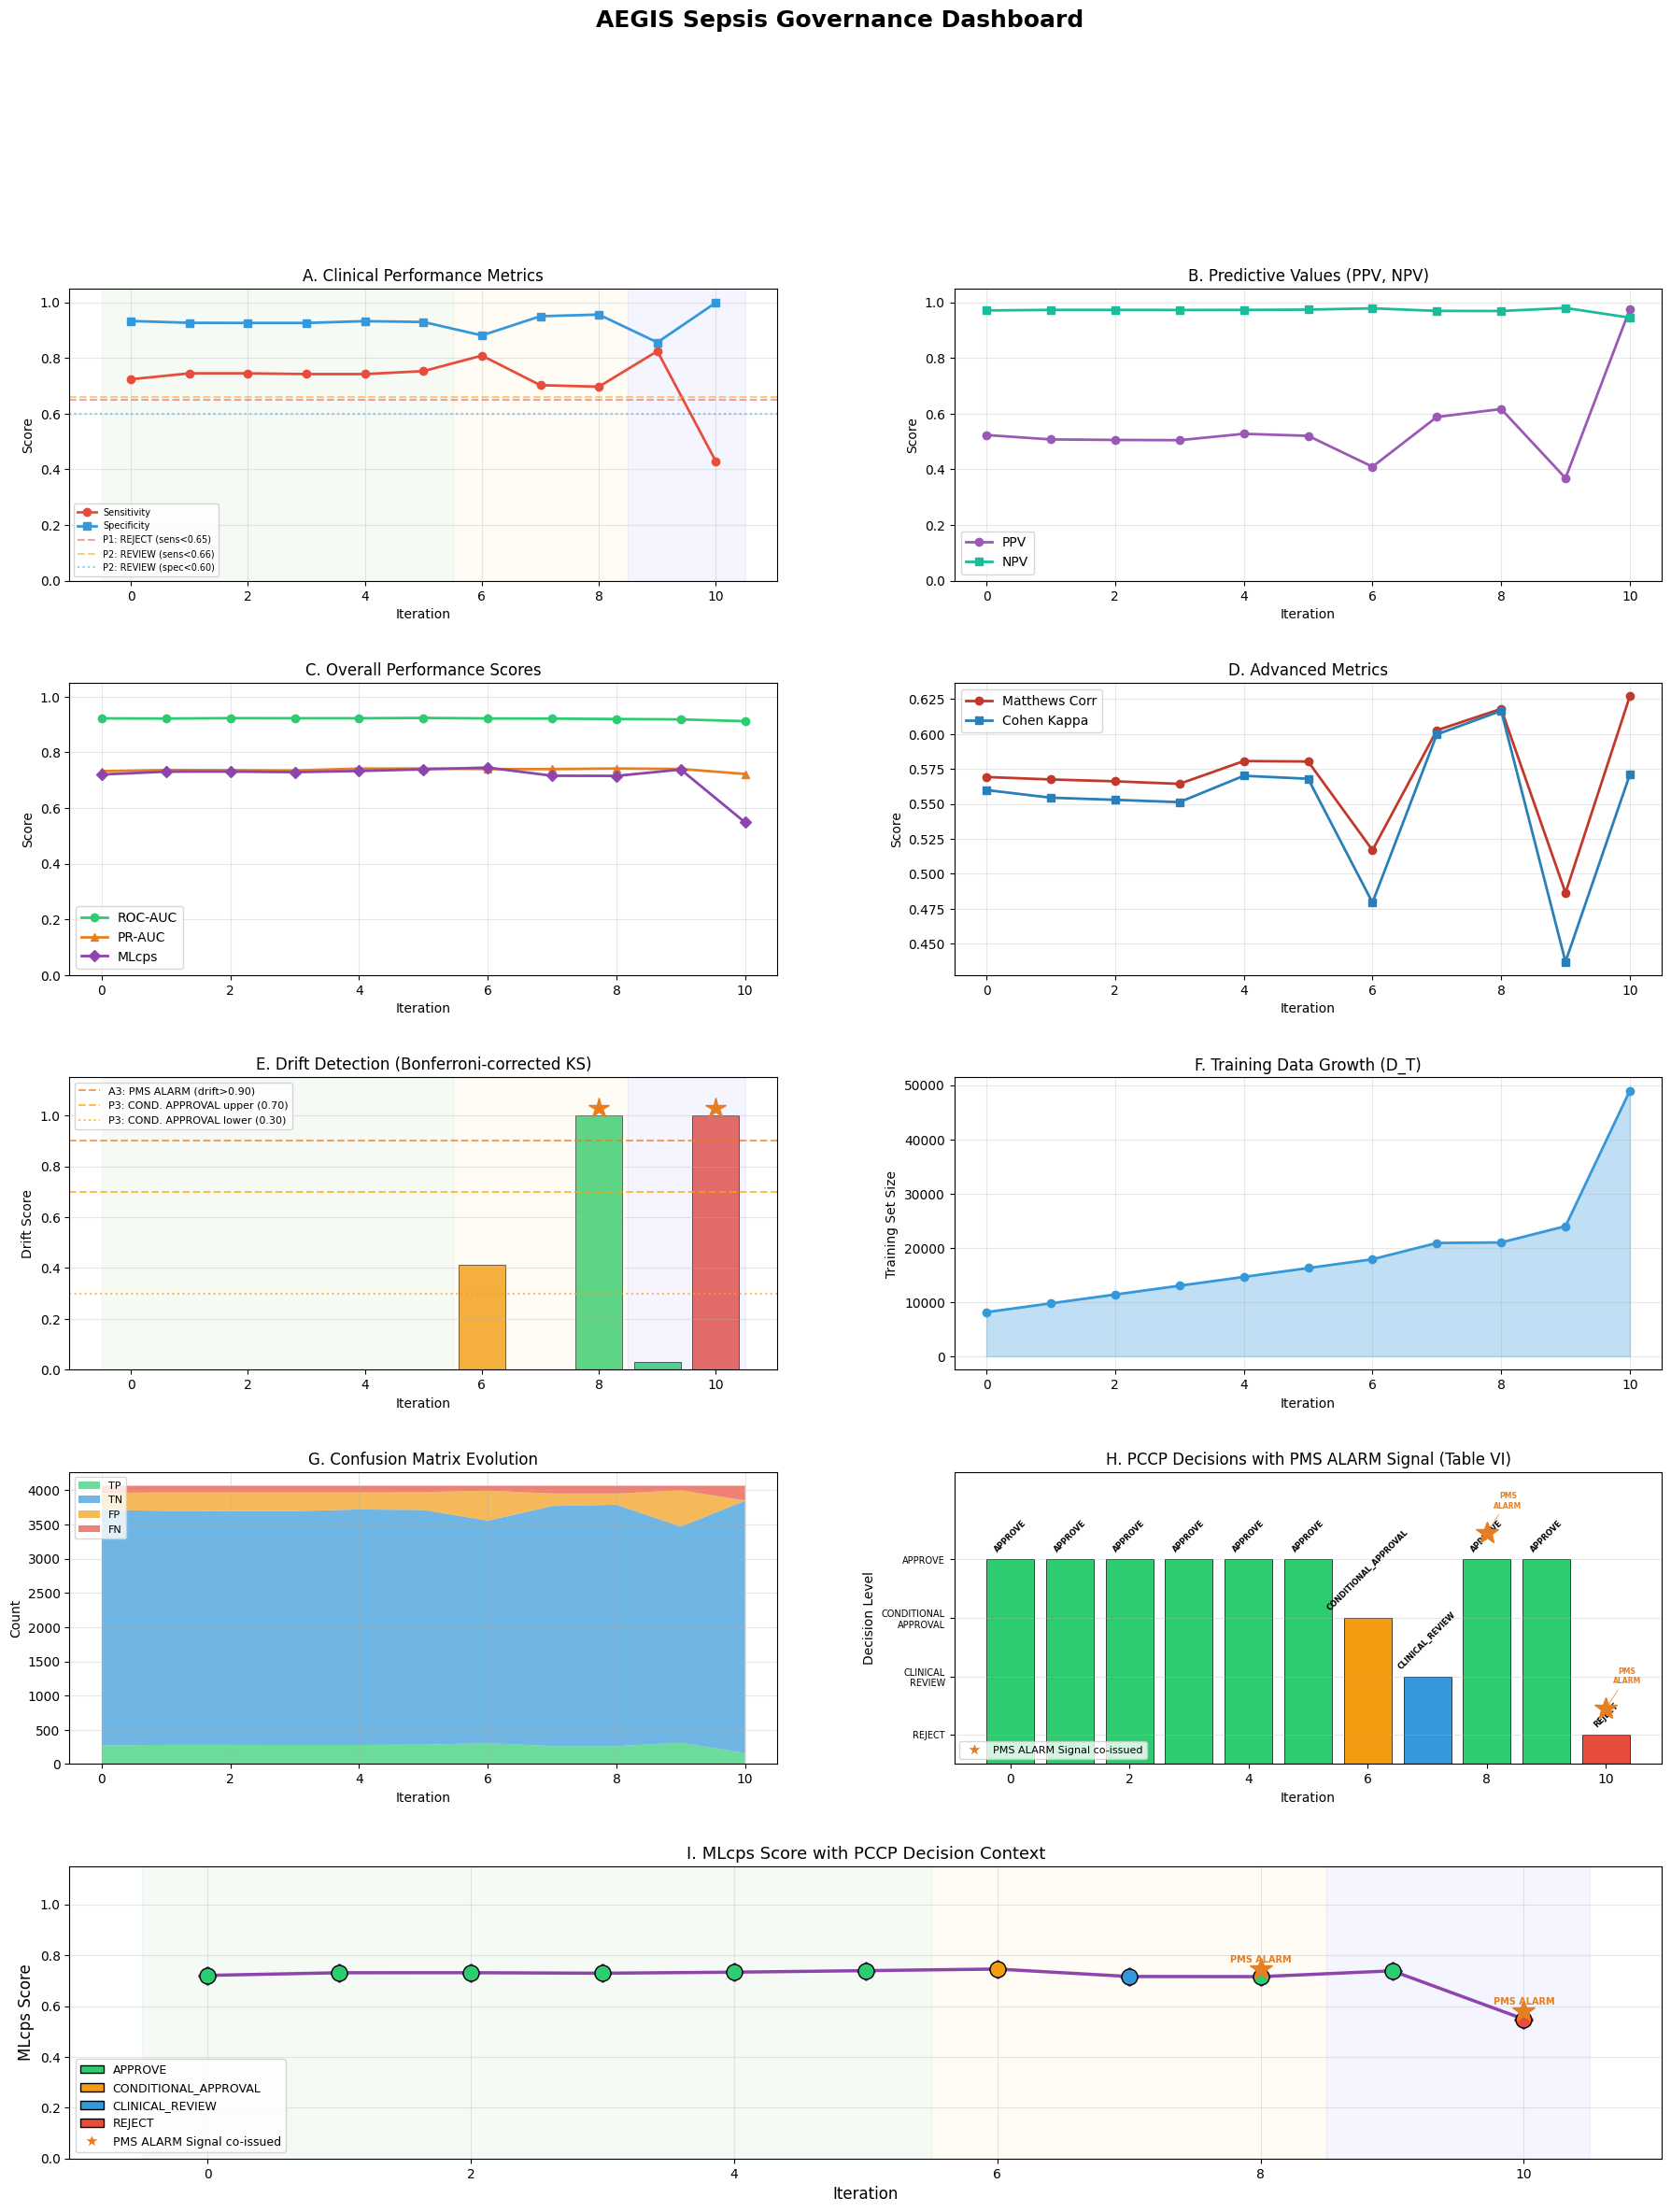

Dashboard saved to /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs/aegis_dashboard.png


In [11]:
# ── Section 6: Results & Visualization ─────────────────────────────────────
history = mmm.kpi_history
iterations = [h["iteration"] for h in history]

# Extract metrics
sens_vals = [h["golden"]["sensitivity"] for h in history]
spec_vals = [h["golden"]["specificity"] for h in history]
auc_vals  = [h["golden"]["roc_auc"] for h in history]
mlcps_vals = [h["golden"]["mlcps"] for h in history]
drift_vals = [h["drift"]["drift_score"] for h in history]
decisions  = [h["decision"] for h in history]
train_sizes = [h["training_size"] for h in history]
ppv_vals = [h["golden"]["ppv"] for h in history]
npv_vals = [h["golden"]["npv"] for h in history]
f1_vals  = [h["golden"]["f1"] for h in history]
mcc_vals = [h["golden"]["matthews_corr"] for h in history]
kappa_vals = [h["golden"]["cohen_kappa"] for h in history]

# 4 PCCP categories only — ALARM is not a bar level
decision_colors = {
    "APPROVE":              "#2ecc71",
    "CONDITIONAL_APPROVAL": "#f39c12",
    "CLINICAL_REVIEW":      "#3498db",
    "REJECT":               "#e74c3c",
}
PMS_ALARM_COLOR  = "#e67e22"
PMS_ALARM_MARKER = "*"

bar_colors = [decision_colors.get(d, "#95a5a6") for d in decisions]
pms_alarm_iters = [h["iteration"] for h in history if h.get("pms_alarm", False)]

# ── Figure: 9-panel dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26))
gs = gridspec.GridSpec(5, 2, hspace=0.35, wspace=0.25)

# Panel A: Clinical Performance (Sensitivity, Specificity)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(iterations, sens_vals, "o-", color="#e74c3c", label="Sensitivity", linewidth=2)
ax1.plot(iterations, spec_vals, "s-", color="#3498db", label="Specificity", linewidth=2)
ax1.axhline(y=0.65, color="#e74c3c", linestyle="--", alpha=0.5, label="P1: REJECT (sens<0.65)")
ax1.axhline(y=0.66, color="#f39c12", linestyle="--", alpha=0.5, label="P2: REVIEW (sens<0.66)")
ax1.axhline(y=0.60, color="#3498db", linestyle=":", alpha=0.5, label="P2: REVIEW (spec<0.60)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Score")
ax1.set_title("A. Clinical Performance Metrics")
ax1.legend(fontsize=7, loc="lower left")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Panel B: Predictive Values
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(iterations, ppv_vals, "o-", color="#9b59b6", label="PPV", linewidth=2)
ax2.plot(iterations, npv_vals, "s-", color="#1abc9c", label="NPV", linewidth=2)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Score")
ax2.set_title("B. Predictive Values (PPV, NPV)")
ax2.legend()
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

# Panel C: Overall Performance (ROC-AUC, PR-AUC, MLcps)
prauc_vals = [h["golden"]["pr_auc"] for h in history]
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(iterations, auc_vals, "o-", color="#2ecc71", label="ROC-AUC", linewidth=2)
ax3.plot(iterations, prauc_vals, "^-", color="#e67e22", label="PR-AUC", linewidth=2)
ax3.plot(iterations, mlcps_vals, "D-", color="#8e44ad", label="MLcps", linewidth=2)
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Score")
ax3.set_title("C. Overall Performance Scores")
ax3.legend()
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3)

# Panel D: Advanced Metrics (MCC, Cohen's Kappa)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(iterations, mcc_vals, "o-", color="#c0392b", label="Matthews Corr", linewidth=2)
ax4.plot(iterations, kappa_vals, "s-", color="#2980b9", label="Cohen Kappa", linewidth=2)
ax4.set_xlabel("Iteration")
ax4.set_ylabel("Score")
ax4.set_title("D. Advanced Metrics")
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel E: Drift Score
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(iterations, drift_vals, color=bar_colors, alpha=0.8, edgecolor="black", linewidth=0.5)
ax5.axhline(y=0.90, color=PMS_ALARM_COLOR, linestyle="--", alpha=0.7, label="A3: PMS ALARM (drift>0.90)")
ax5.axhline(y=0.70, color="orange", linestyle="--", alpha=0.7, label="P3: COND. APPROVAL upper (0.70)")
ax5.axhline(y=0.30, color="orange", linestyle=":", alpha=0.7, label="P3: COND. APPROVAL lower (0.30)")
# Mark PMS ALARM iterations with star
for pi in pms_alarm_iters:
    dv = drift_vals[pi]
    ax5.plot(pi, dv + 0.03, marker=PMS_ALARM_MARKER, color=PMS_ALARM_COLOR,
             markersize=16, zorder=10)
ax5.set_xlabel("Iteration")
ax5.set_ylabel("Drift Score")
ax5.set_title("E. Drift Detection (Bonferroni-corrected KS)")
ax5.legend(fontsize=8)
ax5.set_ylim(0, 1.15)
ax5.grid(True, alpha=0.3, axis="y")

# Panel F: Training Data Growth
ax6 = fig.add_subplot(gs[2, 1])
ax6.fill_between(iterations, train_sizes, alpha=0.3, color="#3498db")
ax6.plot(iterations, train_sizes, "o-", color="#3498db", linewidth=2)
ax6.set_xlabel("Iteration")
ax6.set_ylabel("Training Set Size")
ax6.set_title("F. Training Data Growth (D_T)")
ax6.grid(True, alpha=0.3)

# Panel G: Confusion Matrix Evolution
tp_vals = [h["golden"]["tp"] for h in history]
tn_vals = [h["golden"]["tn"] for h in history]
fp_vals = [h["golden"]["fp"] for h in history]
fn_vals = [h["golden"]["fn"] for h in history]
ax7 = fig.add_subplot(gs[3, 0])
ax7.stackplot(iterations, tp_vals, tn_vals, fp_vals, fn_vals,
              labels=["TP", "TN", "FP", "FN"],
              colors=["#2ecc71", "#3498db", "#f39c12", "#e74c3c"], alpha=0.7)
ax7.set_xlabel("Iteration")
ax7.set_ylabel("Count")
ax7.set_title("G. Confusion Matrix Evolution")
ax7.legend(loc="upper left", fontsize=8)
ax7.grid(True, alpha=0.3)

# Panel H: PCCP Decisions with PMS ALARM Signal
decision_map = {"APPROVE": 4, "CONDITIONAL_APPROVAL": 3, "CLINICAL_REVIEW": 2, "REJECT": 1}
decision_nums = [decision_map.get(d, 0) for d in decisions]
ax8 = fig.add_subplot(gs[3, 1])
ax8.bar(iterations, decision_nums, color=bar_colors, edgecolor="black", linewidth=0.5)
for i_iter, (dec, num) in enumerate(zip(decisions, decision_nums)):
    ax8.text(iterations[i_iter], num + 0.1, dec, ha="center", va="bottom",
             fontsize=6, rotation=45, fontweight="bold")
# PMS ALARM star markers
for pi in pms_alarm_iters:
    num = decision_nums[pi]
    ax8.plot(pi, num + 0.45, marker=PMS_ALARM_MARKER, color=PMS_ALARM_COLOR,
             markersize=18, zorder=10)
    ax8.annotate("PMS\nALARM", xy=(pi, num + 0.45), xytext=(pi + 0.35, num + 0.85),
                 ha="center", va="bottom", fontsize=5.5, fontweight="bold",
                 color=PMS_ALARM_COLOR,
                 arrowprops=dict(arrowstyle="-", color=PMS_ALARM_COLOR, lw=0.5))
ax8.set_xlabel("Iteration")
ax8.set_ylabel("Decision Level")
ax8.set_yticks([1, 2, 3, 4])
ax8.set_yticklabels(["REJECT", "CLINICAL\nREVIEW", "CONDITIONAL\nAPPROVAL", "APPROVE"], fontsize=7)
ax8.set_title("H. PCCP Decisions with PMS ALARM Signal (Table VI)")
ax8.set_ylim(0.5, 5.5)
# Legend with PMS star
from matplotlib.lines import Line2D
legend_h = [Line2D([0], [0], marker=PMS_ALARM_MARKER, color="w",
                    markerfacecolor=PMS_ALARM_COLOR, markersize=12,
                    label="PMS ALARM Signal co-issued")]
ax8.legend(handles=legend_h, loc="lower left", fontsize=8)
ax8.grid(True, alpha=0.3, axis="y")

# Panel I: MLcps with Decision Context
ax9 = fig.add_subplot(gs[4, :])
ax9.plot(iterations, mlcps_vals, "D-", color="#8e44ad", linewidth=2.5, markersize=10, zorder=5)
for i_iter, (dec, mlc) in enumerate(zip(decisions, mlcps_vals)):
    ax9.scatter(iterations[i_iter], mlc, color=decision_colors.get(dec, "gray"),
                s=150, zorder=6, edgecolor="black", linewidth=1)
# PMS ALARM star overlays
for pi in pms_alarm_iters:
    mlc = mlcps_vals[pi]
    ax9.plot(pi, mlc + 0.03, marker=PMS_ALARM_MARKER, color=PMS_ALARM_COLOR,
             markersize=18, zorder=10)
    ax9.annotate("PMS ALARM", (pi, mlc + 0.05), ha="center", va="bottom",
                 fontsize=7, fontweight="bold", color=PMS_ALARM_COLOR)
# Legend: 4 PCCP color patches + 1 star entry
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Patch(facecolor=c, edgecolor="black", label=d)
                   for d, c in decision_colors.items()]
legend_elements.append(Line2D([0], [0], marker=PMS_ALARM_MARKER, color="w",
                              markerfacecolor=PMS_ALARM_COLOR, markersize=12,
                              label="PMS ALARM Signal co-issued"))
ax9.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax9.set_xlabel("Iteration", fontsize=12)
ax9.set_ylabel("MLcps Score", fontsize=12)
ax9.set_title("I. MLcps Score with PCCP Decision Context", fontsize=13)
ax9.set_ylim(0, 1.15)
ax9.grid(True, alpha=0.3)

fig.suptitle("AEGIS Sepsis Governance Dashboard", fontsize=18, fontweight="bold", y=0.995)
# Phase annotations
for ax_ph in [ax1, ax5, ax9]:
    ax_ph.axvspan(-0.5, 5.5, alpha=0.04, color='green')
    ax_ph.axvspan(5.5, 8.5, alpha=0.04, color='orange')
    ax_ph.axvspan(8.5, 10.5, alpha=0.04, color='blue')

plt.savefig(os.path.join(OUTPUT_PATH, "aegis_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to", os.path.join(OUTPUT_PATH, "aegis_dashboard.png"))


In [12]:
# ── Summary Table (Table VIII equivalent) ──────────────────────────────────
print("=" * 80)
print("TABLE VIII: AEGIS Iteration Summary")
print("=" * 80)

rows = []
for h in mmm.kpi_history:
    g = h["golden"]
    reasons = h.get("trigger_reasons", [])
    trigger_str = "; ".join(reasons) if reasons else "—"

    # Released model performance on drifting data
    rod = h.get("released_on_drifting")
    rel_sens = f"{rod['sensitivity']:.3f}" if rod else "—"
    rel_spec = f"{rod['specificity']:.3f}" if rod else "—"

    # Gold standard comparison
    gs = cdm.gold_standard
    if gs and h["iteration"] > 0:
        gs_sens_diff = g["sensitivity"] - gs["sensitivity"]
        gs_spec_diff = g["specificity"] - gs["specificity"]
        gs_str = f"dsens={gs_sens_diff:+.3f} dspec={gs_spec_diff:+.3f}"
    else:
        gs_str = "baseline"

    # PMS ALARM
    pms = "Yes" if h.get("pms_alarm", False) else "—"
    pms_reasons_str = "; ".join(h.get("pms_alarm_reasons", []))

    rows.append({
        "Iter": h["iteration"],
        "|D_T|": f"{h['training_size']:,}",
        "Sens": f"{g['sensitivity']:.3f}",
        "Spec": f"{g['specificity']:.3f}",
        "AUC": f"{g['roc_auc']:.3f}",
        "MLcps": f"{g['mlcps']:.4f}",
        "Dist.Drift": f"{h['drift']['drift_score']:.3f}",
        "Perf.Sens(DD)": rel_sens,
        "Perf.Spec(DD)": rel_spec,
        "Gold Std": gs_str,
        "PCCP": h["decision"],
        "PMS": pms,
        "CDM Trigger": trigger_str,
    })

summary_df = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 80, "display.width", 280):
    print(summary_df.to_string(index=False))
print()
print("Column legend:")
print("  Sens/Spec/AUC/MLcps  : NEW model evaluated on D_G (golden set)")
print("  Dist.Drift           : Bonferroni-KS feature-distribution drift (batch vs D_T)")
print("  Perf.Sens/Spec(DD)   : RELEASED model evaluated on D_D (performance/concept drift)")
print("  Gold Std             : Delta from iteration-0 gold standard (sensitivity, specificity)")
print("  PCCP                 : Primary governance decision (4 levels)")
print("  PMS                  : Post-Market Surveillance ALARM (parallel advisory signal)")
print()

# Decision distribution
print("PCCP Decision distribution:")
for d_name in ["APPROVE", "CONDITIONAL_APPROVAL", "CLINICAL_REVIEW", "REJECT"]:
    count = sum(1 for h in history if h["decision"] == d_name)
    iters = [h["iteration"] for h in history if h["decision"] == d_name]
    print(f"  {d_name:25s}: {count}  (iterations {iters})")

pms_iters = [h["iteration"] for h in history if h.get("pms_alarm", False)]
print(f"\nPMS ALARM co-issued at iterations: {pms_iters}")


TABLE VIII: AEGIS Iteration Summary
 Iter  |D_T|  Sens  Spec   AUC  MLcps Dist.Drift Perf.Sens(DD) Perf.Spec(DD)                  Gold Std                 PCCP PMS                                                              CDM Trigger
    0  8,134 0.723 0.933 0.922 0.7207      0.000             —             —                  baseline              APPROVE   —                        All PCCP criteria satisfied; Gold standard passed
    1  9,760 0.745 0.926 0.922 0.7310      0.000         0.759         0.943 dsens=+0.021 dspec=-0.007              APPROVE   —                        All PCCP criteria satisfied; Gold standard passed
    2 11,386 0.745 0.926 0.923 0.7312      0.000         0.725         0.942 dsens=+0.021 dspec=-0.007              APPROVE   —                        All PCCP criteria satisfied; Gold standard passed
    3 13,012 0.742 0.926 0.923 0.7292      0.000         0.726         0.934 dsens=+0.019 dspec=-0.007              APPROVE   —                        All PCCP 

In [13]:
# ── Regulatory Mapping (FDA PCCP / EU AI Act) ──────────────────────────────
print("=" * 80)
print("REGULATORY MAPPING (FDA PCCP / EU AI Act)")
print("=" * 80)

reg_map = {
    "APPROVE": ("Within PCCP scope", "Art. 43(4) exemption applies",
                "Deploy; update audit log"),
    "CONDITIONAL_APPROVAL": ("Limited PCCP scope", "Enhanced PMS required",
                             "Deploy with increased monitoring frequency"),
    "CLINICAL_REVIEW": ("May exceed PCCP scope", "Pre-modification review",
                        "Human clinical validation before deployment"),
    "REJECT": ("New 510(k) required", "New conformity assessment",
               "Deployment blocked; rollback to last approved model"),
}

for h in mmm.kpi_history:
    dec = h["decision"]
    fda, eu, action = reg_map[dec]
    pms_flag = " + PMS ALARM" if h.get("pms_alarm", False) else ""
    print(f"\n  Iter {h['iteration']:2d}: {dec}{pms_flag}")
    print(f"    FDA PCCP  : {fda}")
    print(f"    EU MDR/AI : {eu}")
    print(f"    Action    : {action}")
    if h.get("pms_alarm"):
        for r in h.get("pms_alarm_reasons", []):
            print(f"    PMS       : {r}")
    print(f"    Trigger   : {'; '.join(h['trigger_reasons'])}")


REGULATORY MAPPING (FDA PCCP / EU AI Act)

  Iter  0: APPROVE
    FDA PCCP  : Within PCCP scope
    EU MDR/AI : Art. 43(4) exemption applies
    Action    : Deploy; update audit log
    Trigger   : All PCCP criteria satisfied; Gold standard passed

  Iter  1: APPROVE
    FDA PCCP  : Within PCCP scope
    EU MDR/AI : Art. 43(4) exemption applies
    Action    : Deploy; update audit log
    Trigger   : All PCCP criteria satisfied; Gold standard passed

  Iter  2: APPROVE
    FDA PCCP  : Within PCCP scope
    EU MDR/AI : Art. 43(4) exemption applies
    Action    : Deploy; update audit log
    Trigger   : All PCCP criteria satisfied; Gold standard passed

  Iter  3: APPROVE
    FDA PCCP  : Within PCCP scope
    EU MDR/AI : Art. 43(4) exemption applies
    Action    : Deploy; update audit log
    Trigger   : All PCCP criteria satisfied; Gold standard passed

  Iter  4: APPROVE
    FDA PCCP  : Within PCCP scope
    EU MDR/AI : Art. 43(4) exemption applies
    Action    : Deploy; update audi

## Section 7 — Export

In [14]:
# ── Section 7: Export ───────────────────────────────────────────────────────
print("=" * 80)
print("EXPORTING RESULTS")
print("=" * 80)

# Export KPI history as JSON
export_data = {
    "framework": "AEGIS",
    "version": "1.1.0",
    "timestamp": datetime.now().isoformat(),
    "config": {
        "golden_fraction": darm.golden_fraction,
        "drift_features": monitoring_config.drift_features,
        "drift_alpha": monitoring_config.drift_alpha,
        "mlcps_weights": monitoring_config.mlcps_weights,
        "pccp_thresholds": {
            "P1_reject_sensitivity": decision_config.critical_sensitivity,
            "P2_review_sensitivity": decision_config.review_sensitivity,
            "P2_review_specificity": decision_config.review_specificity,
            "P3_conditional_drift_low": decision_config.minor_drift_low,
            "P3_conditional_drift_high": decision_config.minor_drift_high,
            "P4_gold_tolerance": decision_config.gold_standard_tolerance,
        },
        "pms_alarm_thresholds": {
            "A1_sensitivity_floor": decision_config.pms_sensitivity_floor,
            "A2_regression_delta": decision_config.pms_regression_delta,
            "A3_major_drift": decision_config.major_drift_threshold,
        },
    },
    "iterations": [],
}

for h in mmm.kpi_history:
    iter_export = {
        "iteration": h["iteration"],
        "pccp_decision": h["decision"],
        "pms_alarm": h.get("pms_alarm", False),
        "pms_alarm_reasons": h.get("pms_alarm_reasons", []),
        "trigger_reasons": h["trigger_reasons"],
        "training_size": h["training_size"],
        "golden_metrics": {k: v for k, v in h["golden"].items()
                          if not isinstance(v, dict)},
        "drift": {
            "drift_score": h["drift"]["drift_score"],
            "n_shifted": h["drift"]["n_shifted"],
            "n_tested": h["drift"]["n_tested"],
            "major_drift": h["drift"]["major_drift"],
            "minor_drift": h["drift"]["minor_drift"],
        },
    }
    if h["drifting"] is not None:
        iter_export["drifting_metrics"] = {
            k: v for k, v in h["drifting"].items() if not isinstance(v, dict)
        }
    if h.get("released_on_drifting"):
        rod = h["released_on_drifting"]
        iter_export["released_on_drifting"] = {
            k: v for k, v in rod.items() if not isinstance(v, dict)
        }
    export_data["iterations"].append(iter_export)

# Save JSON
json_path = os.path.join(OUTPUT_PATH, "aegis_results.json")
with open(json_path, "w") as f:
    json.dump(export_data, f, indent=2, default=str)
print(f"  JSON : {json_path}")

# Save CSV
csv_path = os.path.join(OUTPUT_PATH, "aegis_summary.csv")
summary_df.to_csv(csv_path, index=False)
print(f"  CSV  : {csv_path}")

# Save provenance log
prov_path = os.path.join(OUTPUT_PATH, "aegis_provenance.json")
with open(prov_path, "w") as f:
    json.dump(darm.provenance_log, f, indent=2, default=str)
print(f"  Provenance: {prov_path}")

# Save CDM decision log
cdm_path = os.path.join(OUTPUT_PATH, "aegis_cdm_decisions.json")
with open(cdm_path, "w") as f:
    json.dump(cdm.decision_log, f, indent=2, default=str)
print(f"  CDM log: {cdm_path}")

print()
print("AEGIS notebook complete.")


EXPORTING RESULTS
  JSON : /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs/aegis_results.json
  CSV  : /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs/aegis_summary.csv
  Provenance: /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs/aegis_provenance.json
  CDM log: /Users/sabt/Library/CloudStorage/GoogleDrive-farhad.abtahi@gmail.com/My Drive/SepsisProject/outputs/aegis_cdm_decisions.json

AEGIS notebook complete.
